# Wannier functions in trivial Haldane model

In [1]:
from pythtb import Mesh, Wannier, WFArray
from pythtb.models import haldane
import numpy as np

## Haldane model

Setting up `pythTB` tight-binding model for the Haldane model parameterized by the onsite potential $\Delta$, nearest neighbor hopping $t_1$ and complex next nearest neighbor hopping $t_2$

In [2]:
# tight-binding parameters
delta = t1 = 1
t2 = -0.1
n_super_cell = 2  # number of primitive cells along both lattice vectors

model = haldane(delta, t1, t2).make_supercell([[n_super_cell, 0], [0, n_super_cell]])

## `Wannier` class

The `Wannier`class contains the functions relevant for subspace selection, maximal-localization, and Wannier interpolation. We initialize it by passing the reference `Model` and number of k-points along each dimension in the mesh.

In [3]:
nks = 20, 20 # number of k points along each dimension
mesh = Mesh(dim_k=2, axis_types=['k', 'k'])
mesh.build_grid(shape=nks)
print(mesh)

Mesh Summary
Type: grid
Dimensionality: 2 k-dim(s) + 0 λ-dim(s)
Number of mesh points: 400
Full shape: (20, 20, 2)
k-axes: [Axis(type=k, name=k_0, size=20), Axis(type=k, name=k_1, size=20)]
λ-axes: []
Is a torus in k-space (all k-axes wind BZ): yes
Looped axes: (axis 0 loops component 0), (axis 1 loops component 1)
BZ-winding axes: (axis 0 winds component 0), (axis 1 winds component 1)
Endpoint axes: None


In [4]:
wfa = WFArray(model.lattice, mesh)
wfa.solve_model(model)

In [5]:
WF = Wannier(model, wfa)

## Setting up trial wavefunctions 

Now we must choose trial wavefunctions to construct our Bloch-like states. A natural choice is delta functions on the low-energy sublattice in the home cell. 

The trial wavefunctions are defined by lists of tuples specifying the trial wavefunction's probability amplitude over the orbitals `[(n, c_n), ...]`. 

$$ |t_i \ \rangle = \sum_n c_n |\phi_n\rangle $$


_Note_: Normalization is handled internally so the square of the amplitudes do not need to sum to $1$. Any orbitals not specified are taken to have zero amplitude.

In [6]:
# model specific constants
n_orb = model.norb  # number of orbitals
n_occ = int(n_orb/2)  # number of occupied bands (assume half-filling)
low_E_sites = np.arange(0, n_orb, 2)  # low-energy sites defined to be indexed by even numbers

# defining the trial wavefunctions
tf_list = [ [(orb, 1)] for orb in low_E_sites] 
n_tfs = len(tf_list)

print(f"Trial wavefunctions: {tf_list}")
print(f"# of Wannier functions: {n_tfs}")
print(f"# of occupied bands: {n_occ}")
print(f"Wannier fraction: {n_tfs/n_occ}")

Trial wavefunctions: [[(np.int64(0), 1)], [(np.int64(2), 1)], [(np.int64(4), 1)], [(np.int64(6), 1)]]
# of Wannier functions: 4
# of occupied bands: 4
Wannier fraction: 1.0


In [7]:
WF.set_trial_wfs(tf_list)
WF.trial_wfs

array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]])

In [8]:
WF.num_twfs

4

## Projection step

To obtain the initial Bloch-like states from projection we call the method `optimal_alignment` providing the trial wavefunctions we specified and the band-indices to construct Wannier functions from. This performs the operations,
1. Projection $$ (A_{\mathbf{k}})_{mn} = \langle \psi_{m\mathbf{k}} | t_n \rangle$$
2. SVD $$ A_{\mathbf{k}} = V_{\mathbf{k}} \Sigma_{\mathbf{k}} W_{\mathbf{k}}^{\dagger} $$
3. Unitary rotation$$ |\tilde{\psi}_{n\mathbf{k}} \rangle = \sum_{m\in \text{band idxs}} |\psi_{m\mathbf{k}} \rangle (V_{\mathbf{k}}W_{\mathbf{k}}^{\dagger})_{mn} $$
4. Fourier transformation $$  |\mathbf{R} n\rangle = \sum_{\mathbf{k}} e^{-i\mathbf{k}\cdot \mathbf{R}} |\tilde{\psi}_{n\mathbf{k}} \rangle  $$

In [9]:
WF.single_shot_projection(band_idxs=list(range(n_occ)))

This will already gives us quite localized Wannier functions. We can see their spreads by calling the function `report`.

In [10]:
WF.info()

Wannier Function Report
WF 1: center = [0.50000000, 0.28867513]  Omega     = 0.10437277
WF 2: center = [1.00000000, 1.15470054]  Omega     = 0.10437277
WF 3: center = [1.50000000, 0.28867513]  Omega     = 0.10437277
WF 4: center = [2.00000000, 1.15470054]  Omega     = 0.10437277
Sum : center = [5.00000000, 2.88675135]  Omega tot = 0.41749108
---------------------------------------------------------------
Omega I   = 0.37232887
Omega D   = 0.00401573
Omega OD  = 0.04114648
Omega tot = 0.41749108


We can also directly access the attributes

In [11]:
print(WF.spread)
print(WF.Omega_I)
print(WF.Omega_D)
print(WF.Omega_OD)
print(WF.centers)

omega_tilde_ss = WF.Omega_OD + WF.Omega_D

[0.10437277 0.10437277 0.10437277 0.10437277]
0.3723288655936017
0.004015730767240314
0.04114648120899374
[[0.5        0.28867513]
 [1.         1.15470054]
 [1.5        0.28867513]
 [2.         1.15470054]]


We can visualize the Wannier density using `plot_density`. We specify which Wannier function to look at with `Wan_idx`.

(<Figure size 640x480 with 1 Axes>, <Axes: >)

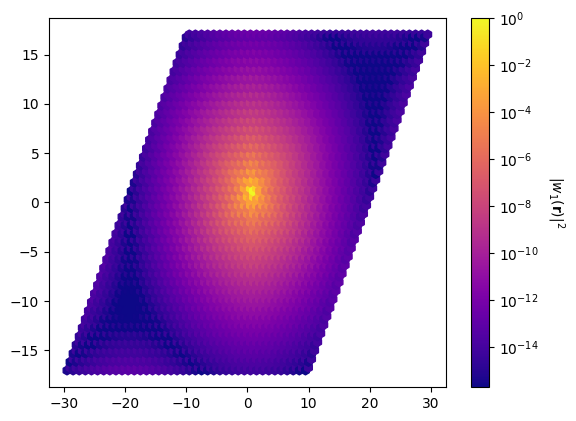

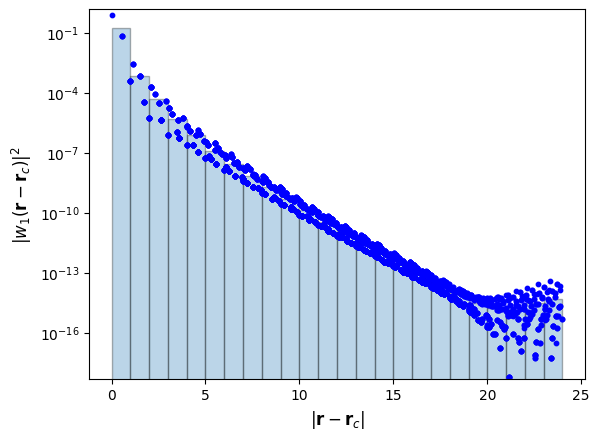

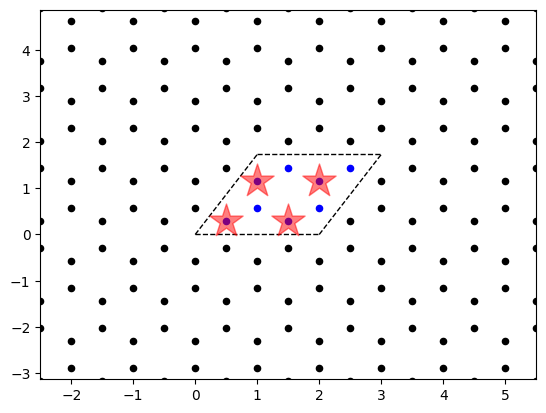

In [12]:
WF.plot_density(wan_idx=1)
WF.plot_decay(wan_idx=1)
WF.plot_centers()

## Maximal Localization

_Maximal localization_ finds the optimal unitary rotation that minimizes the gauge dependent spread $\widetilde{\Omega}$ using the Marzari-Vanderbilt algorithm from PhysRevB.56.12847. 

To do so we call the `max_loc` function, specifying the following
- `eps` is the step size for gradient descent
- `iter_num` is the number of iterations before the calculation stops
- Optionally we can set `tol` specifying the minimum change in the spread at subsequent iterations before convergence
- For additional control we specify `grad_min` which sets the minimum gradient of the spread before convergence.

In [13]:
max_iter = 1000

WF.max_localize(alpha=1/2, max_iter=max_iter, tol=1e-10, grad_min=1e-10, verbose=True)

iter    0 | Ω_tilde = 4.510240683e-02 | ΔΩ = -5.98051e-05 | ‖∇‖ = 1.39672e+01
iter    1 | Ω_tilde = 4.504606310e-02 | ΔΩ = -5.63437e-05 | ‖∇‖ = 1.37964e+01
iter    2 | Ω_tilde = 4.499281579e-02 | ΔΩ = -5.32473e-05 | ‖∇‖ = 1.36278e+01
iter    3 | Ω_tilde = 4.494236449e-02 | ΔΩ = -5.04513e-05 | ‖∇‖ = 1.34612e+01
iter    4 | Ω_tilde = 4.489445696e-02 | ΔΩ = -4.79075e-05 | ‖∇‖ = 1.32967e+01
iter    5 | Ω_tilde = 4.484887799e-02 | ΔΩ = -4.55790e-05 | ‖∇‖ = 1.31341e+01
iter    6 | Ω_tilde = 4.480544166e-02 | ΔΩ = -4.34363e-05 | ‖∇‖ = 1.29736e+01
iter    7 | Ω_tilde = 4.476398566e-02 | ΔΩ = -4.14560e-05 | ‖∇‖ = 1.28149e+01
iter    8 | Ω_tilde = 4.472436699e-02 | ΔΩ = -3.96187e-05 | ‖∇‖ = 1.26583e+01
iter    9 | Ω_tilde = 4.468645876e-02 | ΔΩ = -3.79082e-05 | ‖∇‖ = 1.25035e+01
iter   10 | Ω_tilde = 4.465014762e-02 | ΔΩ = -3.63111e-05 | ‖∇‖ = 1.23506e+01
iter   11 | Ω_tilde = 4.461533170e-02 | ΔΩ = -3.48159e-05 | ‖∇‖ = 1.21996e+01
iter   12 | Ω_tilde = 4.458191903e-02 | ΔΩ = -3.34127e-05 | ‖∇‖ 

Now let's see how the localization improved.

In [15]:
WF.info()

omega_tilde_ml = WF.Omega_OD + WF.Omega_D
print()
print(f"Spread lowered by: {omega_tilde_ss-omega_tilde_ml}")

Wannier Function Report
WF 1: center = [0.50000000, 0.28867513]  Omega     = 0.10396336
WF 2: center = [1.00000000, 1.15470054]  Omega     = 0.10396336
WF 3: center = [1.50000000, 0.28867513]  Omega     = 0.10396336
WF 4: center = [2.00000000, 1.15470054]  Omega     = 0.10396336
Sum : center = [5.00000000, 2.88675135]  Omega tot = 0.41585345
---------------------------------------------------------------
Omega I   = 0.37232887
Omega D   = 0.00396023
Omega OD  = 0.03956435
Omega tot = 0.41585345

Spread lowered by: 0.001637627622292137
